# Qualitative Risk Assessment: Scenario Analytics and Industry Fusion Analytics

**Course:** ALY 6130 - Risk Management Analytics  
**Group 4:** Adwoa Bempomaa, Sara Mathai, Lawrence Dass  
**Date:** March 2026

Analytical techniques from Fleisher and Bensoussan (2015):
- **Scenario Analytics** (Chapter 22): Risk evaluation under multiple plausible futures
- **Industry Fusion Analytics** (Chapter 17): Cross-industry convergence dynamics

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported.')

Libraries imported.


## 1. Scenario Analytics (Fleisher and Bensoussan, 2015, Chapter 22)

In [6]:
# Scenario parameters by risk category
# These directly calibrate the triangular distribution bounds in the Monte Carlo simulation
scenarios = pd.DataFrame({
    'Category': ['Strategic']*3 + ['Regulatory']*3 + ['Financial']*3 + 
                ['Operational']*3 + ['Technical']*3 + ['Market']*3,
    'Scenario': ['Best Case','Most Likely','Worst Case']*6,
    'Description': [
        # Strategic
        'Integration completes by Q3 2026; win rate recovers above 35%',
        'Rival integrations gain ground; win rate holds 25-31% through 2026',
        'Integration delays + aggressive rival bundling; win rate drops below 20%',
        # Regulatory
        'Full CMMC/NIS2/CIRCIA enforcement wave; pipeline growth >40% QoQ',
        'Phased enforcement; pipeline growth 25-35% QoQ; strong conversion',
        'Enforcement delays; pipeline growth slows below 15%; competitor capture',
        # Financial
        'Cross-sell adoption >20% within 18 months; ARR growth sustains 40%+',
        'Cross-sell reaches 12-18%; ARR growth moderates to 30-35%',
        'Cross-sell below 10%; ARR growth drops to 15-20%; goodwill pressure',
        # Operational
        'Dedicated PMO delivers 90%+ milestones on schedule',
        'Integration 70-85% on schedule; minor delays in non-critical paths',
        'Multiple concurrent initiatives create 30%+ milestone delays',
        # Technical
        'Architecture integration completed with <2% sync error rate',
        'Phased integration with 3-4% error rate; customer impact minimal',
        'Architecture incompatibilities cause >5% error rate; customer complaints',
        # Market
        'OT market grows 25%+; cross-sell conversion reaches 20%',
        'OT market grows 15%; cross-sell 12%; stable enterprise spending',
        'Economic slowdown; OT market growth slows to 8%; budget freezes',
    ],
    'Combined_Impact_M': [
        # Strategic (net of upside losses avoided)
        -98.0, -265.0, -417.0,
        # Regulatory (positive)
        +262.9, +119.9, -71.7,
        # Financial
        0.0, -84.5, -217.8,
        # Operational
        -2.0, -37.7, -73.2,
        # Technical
        -4.4, -36.8, -71.6,
        # Market
        +268.6, +140.4, -2.1,
    ]
})

print('Scenario Analysis Framework:')
print('='*90)
for cat in scenarios['Category'].unique():
    subset = scenarios[scenarios['Category']==cat]
    print(f'\n{cat}:')
    for _, row in subset.iterrows():
        sign = '+' if row['Combined_Impact_M'] >= 0 else ''
        print(f"  {row['Scenario']:15s} | Impact: {sign}${row['Combined_Impact_M']:.1f}M")

Scenario Analysis Framework:

Strategic:
  Best Case       | Impact: $-98.0M
  Most Likely     | Impact: $-265.0M
  Worst Case      | Impact: $-417.0M

Regulatory:
  Best Case       | Impact: +$262.9M
  Most Likely     | Impact: +$119.9M
  Worst Case      | Impact: $-71.7M

Financial:
  Best Case       | Impact: +$0.0M
  Most Likely     | Impact: $-84.5M
  Worst Case      | Impact: $-217.8M

Operational:
  Best Case       | Impact: $-2.0M
  Most Likely     | Impact: $-37.7M
  Worst Case      | Impact: $-73.2M

Technical:
  Best Case       | Impact: $-4.4M
  Most Likely     | Impact: $-36.8M
  Worst Case      | Impact: $-71.6M

Market:
  Best Case       | Impact: +$268.6M
  Most Likely     | Impact: +$140.4M
  Worst Case      | Impact: $-2.1M


KeyboardInterrupt: 

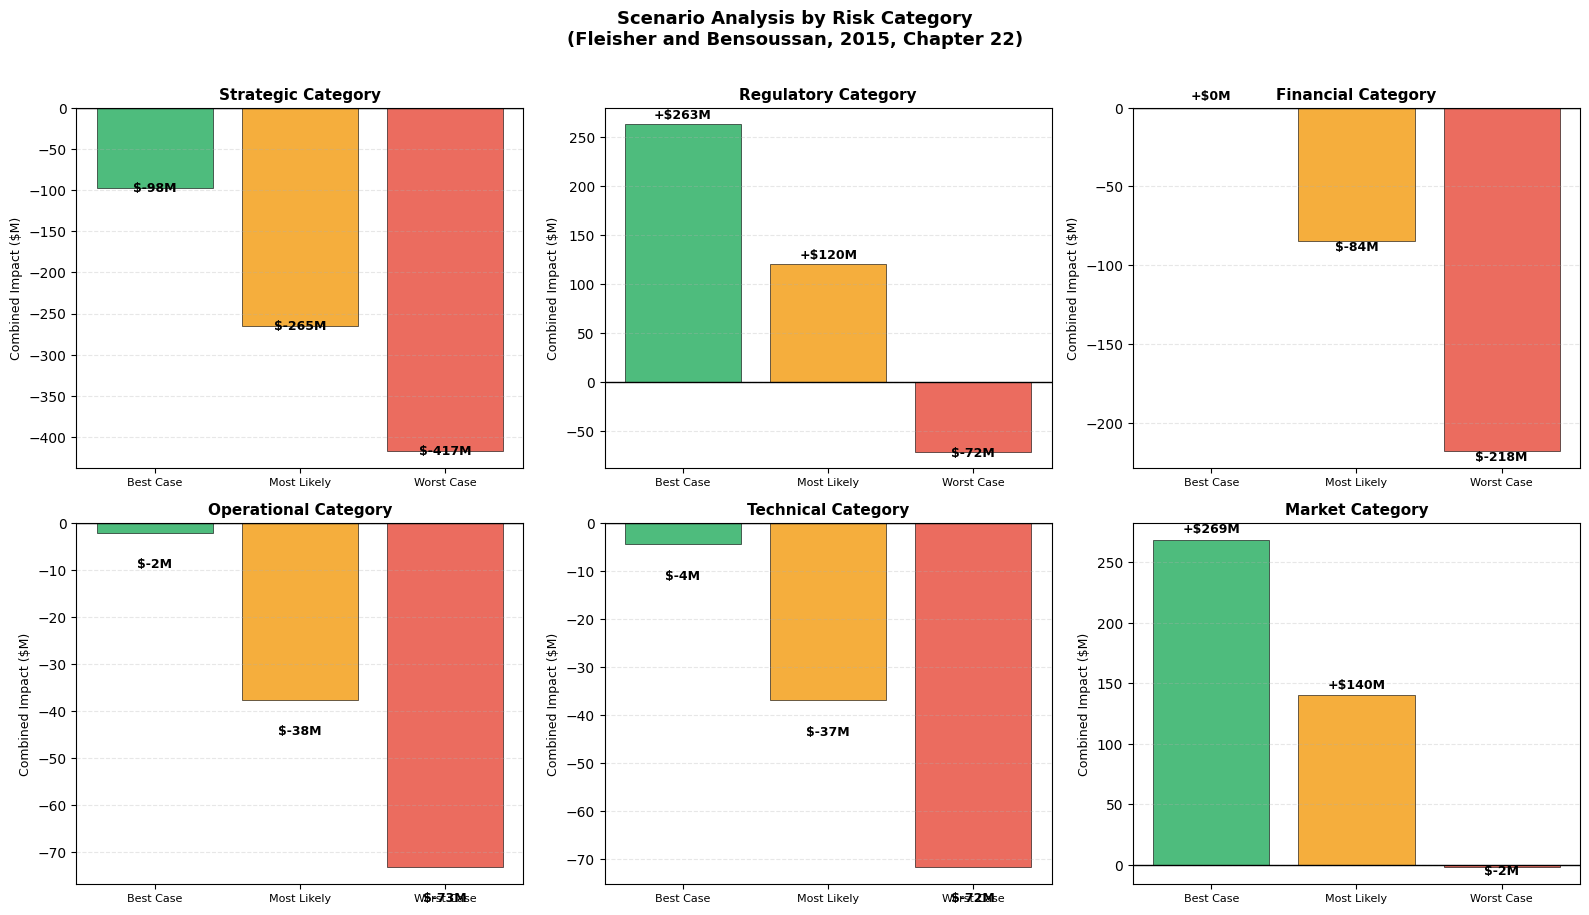

In [7]:
# Visualise scenario ranges by category
categories = scenarios['Category'].unique()
scenario_types = ['Best Case', 'Most Likely', 'Worst Case']
colors_s = {'Best Case': '#27AE60', 'Most Likely': '#F39C12', 'Worst Case': '#E74C3C'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx, cat in enumerate(categories):
    ax = axes[idx // 3][idx % 3]
    subset = scenarios[scenarios['Category']==cat]
    vals = subset['Combined_Impact_M'].values
    cols = [colors_s[s] for s in subset['Scenario']]
    bars = ax.bar(scenario_types, vals, color=cols,
                  edgecolor='black', linewidth=0.5, alpha=0.82)
    ax.axhline(0, color='black', lw=1)
    for bar, v in zip(bars, vals):
        sign = '+' if v >= 0 else ''
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (3 if v >= 0 else -8),
                f'{sign}${v:.0f}M', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title(f'{cat} Category', fontsize=11, fontweight='bold')
    ax.set_ylabel('Combined Impact ($M)', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.suptitle('Scenario Analysis by Risk Category\n(Fleisher and Bensoussan, 2015, Chapter 22)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/qualitative_scenario_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: qualitative_scenario_analysis.png')

## 2. Industry Fusion Analytics (Fleisher and Bensoussan, 2015, Chapter 17)

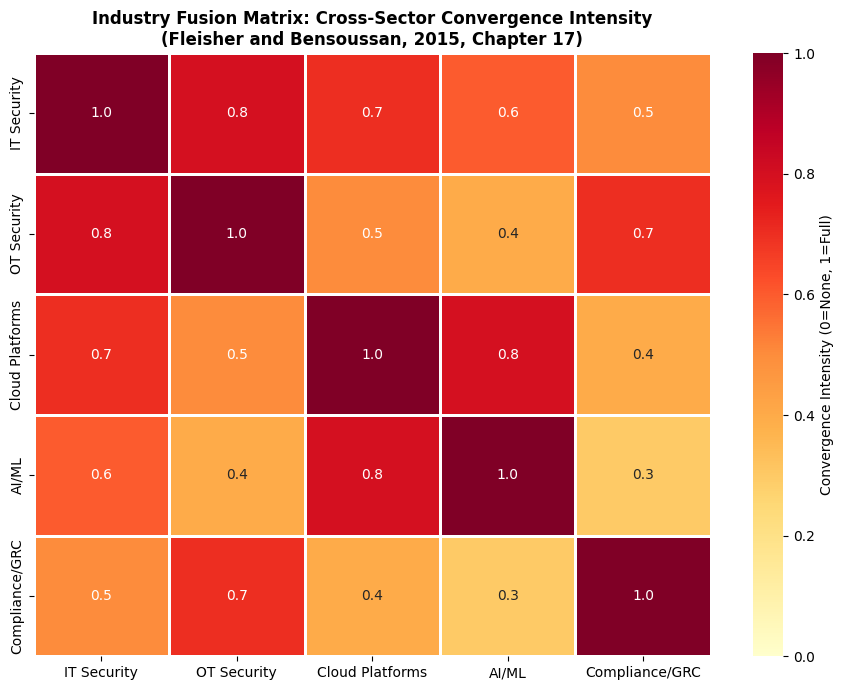

Key Convergence Insights:
  IT/OT Security (0.8)   -> Amplifies R1 (Competitive Displacement) and R17 (Customer Migration)
  Cloud/AI (0.8)         -> Drives R2 (AI Convergence) and R13 (AI Obsolescence)
  OT/Compliance (0.7)    -> Enables R3 (Regulatory Demand) - positive risk driver
  IT/Cloud (0.7)         -> Supports R4 (Market Consolidation) dynamics


In [ ]:
# Industry convergence matrix
sectors = ['IT Security', 'OT Security', 'Cloud Platforms', 'AI/ML', 'Compliance/GRC']
fusion_matrix = pd.DataFrame({
    'IT Security':     [1.0, 0.8, 0.7, 0.6, 0.5],
    'OT Security':     [0.8, 1.0, 0.5, 0.4, 0.7],
    'Cloud Platforms': [0.7, 0.5, 1.0, 0.8, 0.4],
    'AI/ML':           [0.6, 0.4, 0.8, 1.0, 0.3],
    'Compliance/GRC':  [0.5, 0.7, 0.4, 0.3, 1.0],
}, index=sectors)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(fusion_matrix, annot=True, cmap='YlOrRd', vmin=0, vmax=1,
            fmt='.1f', linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Convergence Intensity (0=None, 1=Full)'})
ax.set_title('Industry Fusion Matrix: Cross-Sector Convergence Intensity\n'
             '(Fleisher and Bensoussan, 2015, Chapter 17)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/qualitative_industry_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key Convergence Insights:')
print('  IT/OT Security (0.8)   -> Amplifies R1 (Competitive Displacement) and R17 (Customer Migration)')
print('  Cloud/AI (0.8)         -> Drives R2 (AI Convergence) and R13 (AI Obsolescence)')
print('  OT/Compliance (0.7)    -> Enables R3 (Regulatory Demand) - positive risk driver')
print('  IT/Cloud (0.7)         -> Supports R4 (Market Consolidation) dynamics')

## 3. Qualitative Assessment Conclusion

Both analytical techniques confirm that all 25 risks exhibit sufficient variability in potential
outcomes to warrant quantitative analysis:

- **Strategic risks** show a scenario range from -$98M (best) to -$417M (worst), confirming high sensitivity to integration execution timing
- **Regulatory risks** are the only category where the best-case scenario substantially exceeds zero (+$262.9M), validating the Exploit strategy for R3
- **IT/OT convergence intensity of 0.8** confirms that platform players from both domains directly compete for the same enterprise budget
- **Cloud/AI convergence of 0.8** confirms the structural nature of the AI parity risk (R2, R13)

These qualitative findings directly inform the triangular distribution parameters used in the
Monte Carlo simulation (see monte_carlo.ipynb).